# Female Tennis Match Prediction

## Project Overview
The objective of this investigation is to identify and explore the qualities that contribute to successful performance, focusing specifically on female tennis players who excel on hard court surfaces.

## Project Objective
Can match-performance statistics predict whether Player 1 wins or loses a women’s Grand Slam tennis match?

In [97]:
# Import Libararies 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
import gc
from datetime import datetime, date, timedelta

from scipy.stats import zscore, skew
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn import tree
from sklearn.metrics import (precision_score, recall_score, auc, roc_curve, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score)

In [98]:
# Load all Datasets 
Aus_F_T = pd.read_csv('AusOpen-women-2013.csv')
Fre_F_T = pd.read_csv('FrenchOpen-women-2013.csv')
US_F_T = pd.read_csv('USOpen-women-2013.csv')
Wimb_F_T = pd.read_csv('Wimbledon-women-2013.csv')

In [99]:
# Data Integration and Column Standardisation
print("AusOpen women 2013\n",Aus_F_T.columns)
print("\nFrenchOpen women 2013\n",Fre_F_T.columns)
print("\nUSOpen women 2013\n",US_F_T.columns)
print("\nWimbledon-women-2013\n",Wimb_F_T.columns)

AusOpen women 2013
 Index(['Player1', 'Player2', 'Round', 'Result', 'FNL1', 'FNL2', 'FSP.1',
       'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1',
       'BPW.1', 'NPA.1', 'NPW.1', 'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1',
       'ST5.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2',
       'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2', 'TPW.2', 'ST1.2', 'ST2.2',
       'ST3.2', 'ST4.2', 'ST5.2'],
      dtype='str')

FrenchOpen women 2013
 Index(['Player1', 'Player2', 'Round', 'Result', 'FNL.1', 'FNL.2', 'FSP.1',
       'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1',
       'BPW.1', 'NPA.1', 'NPW.1', 'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1',
       'ST5.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2',
       'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2', 'TPW.2', 'ST1.2', 'ST2.2',
       'ST3.2', 'ST4.2', 'ST5.2'],
      dtype='str')

USOpen women 2013
 Index(['Player 1', 'Player 2', 'ROUND', 'Result'

In [100]:
# Show all Columns
all_cols = [set(df.columns) for df in [Wimb_F_T, US_F_T, Fre_F_T, Aus_F_T]]
common_cols = set.intersection(*all_cols)
print("Common columns in all datasets:", common_cols)

# Print Columns that are not common
all_columns = set.union(*all_cols)
print("Columns not common across all datasets:", all_columns - common_cols)

Common columns in all datasets: {'UFE.2', 'UFE.1', 'BPC.1', 'BPW.1', 'ST2.2', 'WNR.2', 'ST4.2', 'ACE.2', 'NPA.1', 'BPC.2', 'DBF.1', 'BPW.2', 'FSW.2', 'ST4.1', 'ST1.1', 'SSW.2', 'DBF.2', 'Result', 'SSP.2', 'ST5.1', 'FSW.1', 'ST5.2', 'SSW.1', 'ACE.1', 'ST3.1', 'ST2.1', 'WNR.1', 'TPW.2', 'FSP.1', 'TPW.1', 'ST3.2', 'SSP.1', 'FSP.2', 'NPA.2', 'NPW.2', 'NPW.1'}
Columns not common across all datasets: {'FNL2', 'Player2', 'Round', 'Player 1', 'ST1.2', 'FNL1', 'ST1.1.1', 'FNL.2', 'ST2.1.1', 'FNL.1', 'Player 2', 'Player1', 'ROUND'}


In [101]:
# Change certain columns names within Aus Open
rename_dict_Aus_F_T = {
    'FNL1': 'FNL.1',
    'FNL2': 'FNL.2'
}
Aus_F_T = Aus_F_T.rename(columns=rename_dict_Aus_F_T)

print(Aus_F_T.columns)

Index(['Player1', 'Player2', 'Round', 'Result', 'FNL.1', 'FNL.2', 'FSP.1',
       'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1',
       'BPW.1', 'NPA.1', 'NPW.1', 'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1',
       'ST5.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2',
       'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2', 'TPW.2', 'ST1.2', 'ST2.2',
       'ST3.2', 'ST4.2', 'ST5.2'],
      dtype='str')


In [102]:
# Change certain columns names within US Open
rename_dict_US_F_T = {
    'Player 1': 'Player1',
    'Player 2': 'Player2',
    'ROUND'   : 'Round',
    'ST2.1.1' :  'ST1.2'
}
US_F_T = US_F_T.rename(columns=rename_dict_US_F_T)

print(US_F_T.columns)

Index(['Player1', 'Player2', 'Round', 'Result', 'FNL.1', 'FNL.2', 'FSP.1',
       'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1',
       'BPW.1', 'NPA.1', 'NPW.1', 'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1',
       'ST5.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2',
       'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2', 'TPW.2', 'ST1.2', 'ST2.2',
       'ST3.2', 'ST4.2', 'ST5.2'],
      dtype='str')


In [103]:
# Change certain columns names within Wimbledon 
rename_dict_Wimb_F_T = {
    'ST1.1.1' :  'ST1.2'
}
Wimb_F_T = Wimb_F_T.rename(columns=rename_dict_Wimb_F_T)

print(Wimb_F_T.columns)

Index(['Player1', 'Player2', 'Round', 'Result', 'FNL.1', 'FNL.2', 'FSP.1',
       'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1',
       'BPW.1', 'NPA.1', 'NPW.1', 'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1',
       'ST5.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2',
       'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2', 'TPW.2', 'ST1.2', 'ST2.2',
       'ST3.2', 'ST4.2', 'ST5.2'],
      dtype='str')


In [104]:
all_cols = [set(df.columns) for df in [Wimb_F_T, US_F_T, Fre_F_T, Aus_F_T]]

# Columns that were not common have duplicates or not
all_columns = set.union(*all_cols)
print("Columns that were not common have duplicates or not across all datasets:", all_columns - common_cols)

Columns that were not common have duplicates or not across all datasets: {'Player2', 'Round', 'ST1.2', 'FNL.2', 'FNL.1', 'Player1'}


In [105]:
# Merge all columns
Female_Tennis_dataset = pd.concat([Wimb_F_T, US_F_T, Fre_F_T, Aus_F_T], ignore_index=True)

## Data Exploration & Data Cleaning 

In [106]:
Female_Tennis_dataset.head()

,Player1,Player2,Round,Result,FNL.1,FNL.2,FSP.1,FSW.1,SSP.1,SSW.1,...,BPC.2,BPW.2,NPA.2,NPW.2,TPW.2,ST1.2,ST2.2,ST3.2,ST4.2,ST5.2
0,M.Koehler,V.Azarenka,1,0,0.0,2.0,60,21,40,8,...,16.0,6.0,8.0,4.0,NaN,6.0,6.0,NaN,NaN,NaN
1,E.Baltacha,F.Pennetta,1,0,0.0,2.0,69,23,31,6,...,6.0,5.0,14.0,11.0,NaN,6.0,6.0,NaN,NaN,NaN
2,S-W.Hsieh,T.Maria,1,1,2.0,0.0,63,17,37,10,...,1.0,0.0,8.0,2.0,NaN,1.0,0.0,NaN,NaN,NaN
3,A.Cornet,V.King,1,1,2.0,1.0,57,36,43,21,...,4.0,1.0,48.0,32.0,NaN,6.0,3.0,1.0,NaN,NaN
4,Y.Putintseva,K.Flipkens,1,0,0.0,2.0,73,34,27,12,...,9.0,3.0,35.0,24.0,NaN,7.0,6.0,NaN,NaN,NaN


In [107]:
Female_Tennis_dataset.shape

(452, 42)

In [108]:
Female_Tennis_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 42 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player1  452 non-null    str    
 1   Player2  452 non-null    str    
 2   Round    452 non-null    int64  
 3   Result   452 non-null    int64  
 4   FNL.1    451 non-null    float64
 5   FNL.2    451 non-null    float64
 6   FSP.1    452 non-null    int64  
 7   FSW.1    452 non-null    int64  
 8   SSP.1    452 non-null    int64  
 9   SSW.1    452 non-null    int64  
 10  ACE.1    430 non-null    float64
 11  DBF.1    448 non-null    float64
 12  WNR.1    452 non-null    int64  
 13  UFE.1    452 non-null    int64  
 14  BPC.1    451 non-null    float64
 15  BPW.1    451 non-null    float64
 16  NPA.1    428 non-null    float64
 17  NPW.1    429 non-null    float64
 18  TPW.1    254 non-null    float64
 19  ST1.1    451 non-null    float64
 20  ST2.1    449 non-null    float64
 21  ST3.1    139 non-null    fl

In [109]:
# Columns seperated by data type
category = Female_Tennis_dataset.select_dtypes(include=['object']).columns
num = Female_Tennis_dataset.select_dtypes(include=['int64','float64']).columns

print("Categorical attributes\n",category)

print("\nNumerical attributes\n",num)

Categorical attributes
 Index(['Player1', 'Player2'], dtype='str')

Numerical attributes
 Index(['Round', 'Result', 'FNL.1', 'FNL.2', 'FSP.1', 'FSW.1', 'SSP.1', 'SSW.1',
       'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1', 'BPW.1', 'NPA.1', 'NPW.1',
       'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1', 'ST5.1', 'FSP.2', 'FSW.2',
       'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2', 'UFE.2', 'BPC.2', 'BPW.2',
       'NPA.2', 'NPW.2', 'TPW.2', 'ST1.2', 'ST2.2', 'ST3.2', 'ST4.2', 'ST5.2'],
      dtype='str')


In [110]:
Female_Tennis_dataset.describe()

,Round,Result,FNL.1,FNL.2,FSP.1,FSW.1,SSP.1,SSW.1,ACE.1,DBF.1,...,BPC.2,BPW.2,NPA.2,NPW.2,TPW.2,ST1.2,ST2.2,ST3.2,ST4.2,ST5.2
count,452.000000,452.000000,451.000000,451.000000,452.000000,452.000000,452.000000,452.000000,430.000000,448.000000,...,451.000000,451.000000,428.000000,429.000000,254.000000,451.000000,449.000000,139.000000,0.0,0.0
mean,2.008850,0.497788,1.159645,1.144124,62.648230,27.426991,37.440265,11.637168,2.834884,3.296875,...,5.702882,6.152993,11.128505,10.829837,69.862205,4.565410,4.572383,4.798561,NaN,NaN
std,1.306613,0.500549,0.900007,0.911204,8.315437,10.276077,8.311212,5.199457,2.626420,2.378838,...,3.855785,4.167185,9.326743,7.756303,23.567763,1.953243,2.039727,1.907954,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,40.000000,3.000000,14.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,1.000000,0.000000,0.000000,0.000000,57.000000,21.000000,32.000000,8.000000,1.000000,1.000000,...,3.000000,3.000000,5.000000,5.000000,56.000000,3.000000,3.000000,3.500000,NaN,NaN
50%,2.000000,0.000000,1.000000,1.000000,63.000000,27.000000,37.000000,11.000000,2.000000,3.000000,...,5.000000,6.000000,9.000000,9.000000,66.000000,6.000000,6.000000,6.000000,NaN,NaN
75%,3.000000,1.000000,2.000000,2.000000,68.000000,34.000000,43.000000,15.000000,4.000000,5.000000,...,7.500000,9.000000,14.250000,14.000000,87.000000,6.000000,6.000000,6.000000,NaN,NaN
max,7.000000,1.000000,2.000000,2.000000,86.000000,57.000000,60.000000,28.000000,14.000000,13.000000,...,20.000000,20.000000,71.000000,48.000000,135.000000,7.000000,7.000000,9.000000,NaN,NaN


In [111]:
# Return the number of duplicates within dataset 
print(Female_Tennis_dataset.duplicated().sum())

0


In [137]:
# Check the number of missing values in each column
missing_values = Female_Tennis_dataset.isnull().sum()

# Calculate percentage of missing values in each column
missing_percentage = (
    Female_Tennis_dataset.isnull().mean() * 100
)

# Display only columns containing missing values
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

print(missing_summary)

       Missing Values  Missing Percentage (%)
FNL.1               1                0.221239
FNL.2               1                0.221239
ACE.1              22                4.867257
DBF.1               4                0.884956
BPC.1               1                0.221239
BPW.1               1                0.221239
NPA.1              24                5.309735
NPW.1              23                5.088496
TPW.1             198               43.805310
ST1.1               1                0.221239
ST2.1               3                0.663717
ST3.1             313               69.247788
ST4.1             452              100.000000
ST5.1             452              100.000000
ACE.2              22                4.867257
DBF.2               4                0.884956
BPC.2               1                0.221239
BPW.2               1                0.221239
NPA.2              24                5.309735
NPW.2              23                5.088496
TPW.2             198             

In [138]:
# Drop Columns that have complete missing values
cols_to_drop = ['ST4.1','ST4.2','ST5.1','ST5.2','ST3.1','ST3.2','TPW.1','TPW.2']
Female_Tennis_dataset_1 = Female_Tennis_dataset.drop(columns=cols_to_drop)

In [140]:
# View Updated dataset
Female_Tennis_dataset_1.columns

Index(['Player1', 'Player2', 'Round', 'Result', 'FNL.1', 'FNL.2', 'FSP.1',
       'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1',
       'BPW.1', 'NPA.1', 'NPW.1', 'ST1.1', 'ST2.1', 'FSP.2', 'FSW.2', 'SSP.2',
       'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2', 'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2',
       'NPW.2', 'ST1.2', 'ST2.2'],
      dtype='str')

In [141]:
Female_Tennis_dataset_1.shape

(452, 34)

In [142]:
# Replace smaller percentage missing value attributes to there median values 
cols_fillna = ['NPA.2', 'NPA.1', 'NPW.2', 'NPW.1','ACE.1', 'ACE.2', 'DBF.2', 'DBF.1','ST2.2', 'ST2.1', 'FNL.2', 'FNL.1','BPW.2', 
               'BPW.1', 'BPC.2', 'BPC.1','ST1.1', 'ST1.2']

for col in cols_fillna:
    Female_Tennis_dataset_1[col] = (Female_Tennis_dataset_1[col].fillna(Female_Tennis_dataset_1[col].median()))

In [143]:
# Update after missing values conduct 
Female_Tennis_dataset_1.isnull().sum() 
num_missing = Female_Tennis_dataset_1.isnull().sum() 
print(num_missing) 

Player1    0
Player2    0
Round      0
Result     0
FNL.1      0
FNL.2      0
FSP.1      0
FSW.1      0
SSP.1      0
SSW.1      0
ACE.1      0
DBF.1      0
WNR.1      0
UFE.1      0
BPC.1      0
BPW.1      0
NPA.1      0
NPW.1      0
ST1.1      0
ST2.1      0
FSP.2      0
FSW.2      0
SSP.2      0
SSW.2      0
ACE.2      0
DBF.2      0
WNR.2      0
UFE.2      0
BPC.2      0
BPW.2      0
NPA.2      0
NPW.2      0
ST1.2      0
ST2.2      0
dtype: int64


In [144]:
# Select numeric columns correctly
num_columns = Female_Tennis_dataset_1.select_dtypes(include=[np.number]).columns

# Apply z-score
z_s = zscore(Female_Tennis_dataset_1[num_columns], nan_policy='omit')

# Identify outliers
outliers = (np.abs(z_s) > 3).any(axis=1)

# Count results
total_rows = len(Female_Tennis_dataset_1)
num_outliers = outliers.sum()
percent_outliers = (num_outliers / total_rows) * 100

print(f"Total records: {total_rows}")
print(f"Number of outliers: {num_outliers}")
print(f"Percentage of outliers: {percent_outliers:.2f}%")

Total records: 452
Number of outliers: 68
Percentage of outliers: 15.04%


In [119]:
# Create a copy of new dataset
df_capped = Female_Tennis_dataset_1.copy()

num_col = df_capped.select_dtypes(include=[np.number]).columns

# Loop through each numeric column and cap outliers
for col in num_col:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_cap = Q1 - 1.5 * IQR
    upper_cap = Q3 + 1.5 * IQR

    # Apply the capping
    df_capped[col] = np.where(df_capped[col] < lower_cap, lower_cap, np.where(df_capped[col] > upper_cap, upper_cap, df_capped[col]))

print("Original DataFrame", Female_Tennis_dataset_1.shape)
print("Capping Outliers:", df_capped.shape)

Original DataFrame (452, 34)
Capping Outliers: (452, 34)


## Exploratory Data Analysis (EDA)

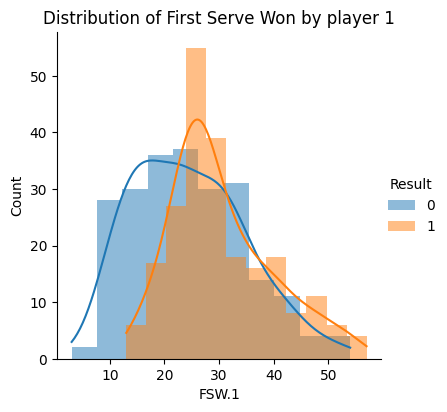

In [120]:
# Distribution of First Serve Won by player 1
sns.FacetGrid(Female_Tennis_dataset_1, hue="Result", height=4).map(sns.histplot, "FSW.1", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of First Serve Won by player 1")
plt.show()

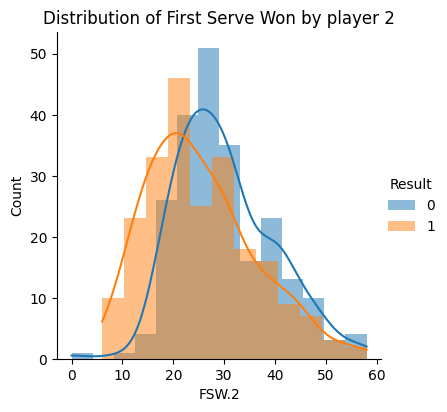

In [121]:
# Distribution  of First Serve Won by player 2
sns.FacetGrid(Female_Tennis_dataset_1, hue="Result", height=4).map(sns.histplot, "FSW.2", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of First Serve Won by player 2")
plt.show()

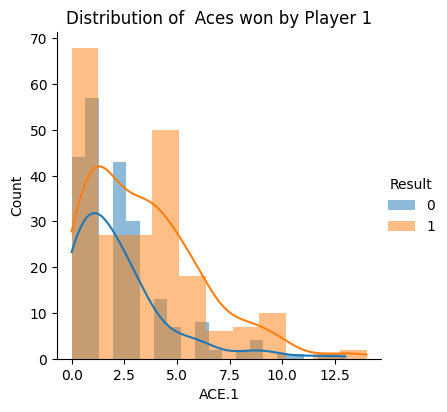

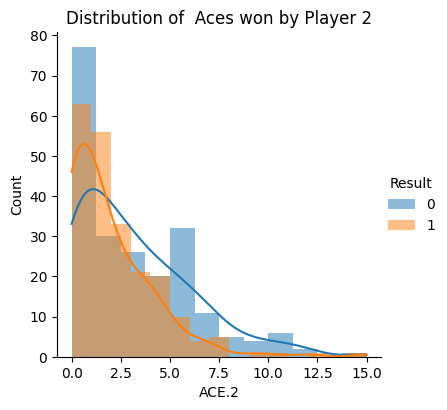

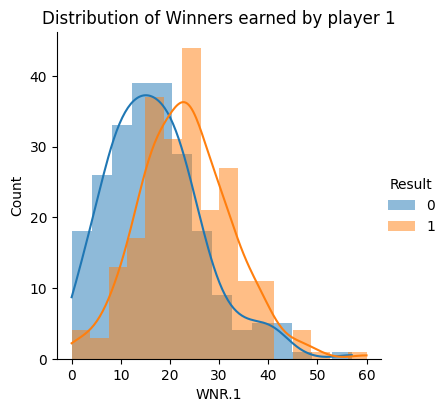

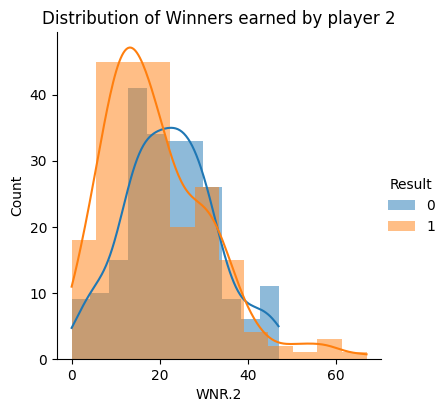

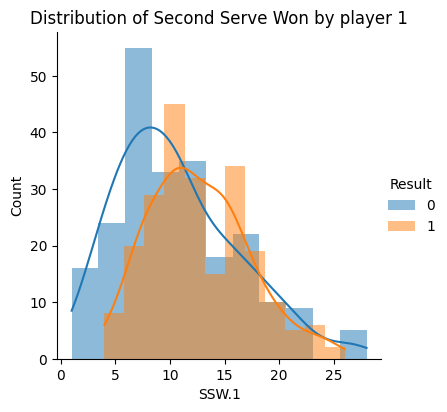

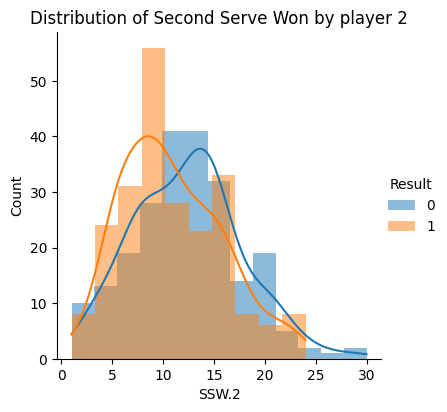

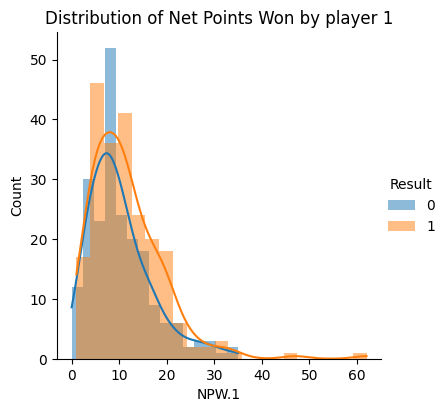

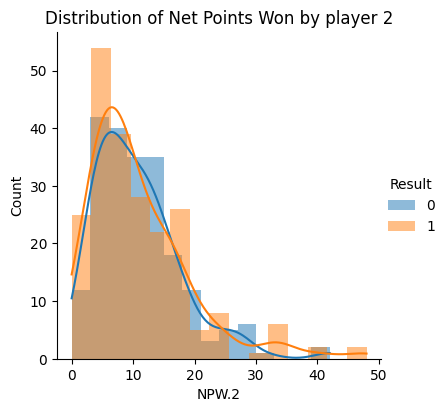

In [122]:
# Distribution of Aces won by Player 1
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "ACE.1", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of  Aces won by Player 1")
plt.show()

# Distribution of Aces won by Player 2
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "ACE.2", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of  Aces won by Player 2")
plt.show()

# --------------------------------------------------------------
# Distribution of Winners earned by player 1 WNR
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "WNR.1", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of Winners earned by player 1")
plt.show()

# Distribution of Winners earned  by player 2 WNR
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "WNR.2", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of Winners earned by player 2")
plt.show()

# --------------------------------------------------------------

# Distribution of Second Serve Won by player 1 SSW
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "SSW.1", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of Second Serve Won by player 1")
plt.show()

# Distribution of Second Serve Won by player 2 SSW
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "SSW.2", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of Second Serve Won by player 2")
plt.show()

# --------------------------------------------------------------

# Distribution of Net Points Won by player 1 NPW
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "NPW.1", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of Net Points Won by player 1")
plt.show()

# Distribution of Net Points Won by player 2 NPW
sns.FacetGrid(Female_Tennis_dataset, hue="Result", height=4).map(sns.histplot, "NPW.2", kde=True, edgecolor=None, linewidth=0).add_legend()
plt.title("Distribution of Net Points Won by player 2")
plt.show()

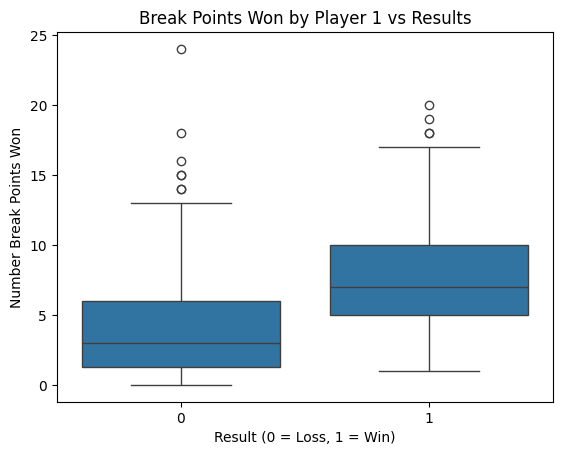

In [123]:
# Visual boxplot of Break Points Won vs Result (PLAYER 1)
sns.boxplot(x='Result', y='BPW.1', data=Female_Tennis_dataset_1)
plt.title('Break Points Won by Player 1 vs Results')
plt.xlabel('Result (0 = Loss, 1 = Win)')
plt.ylabel('Number Break Points Won')
plt.show()

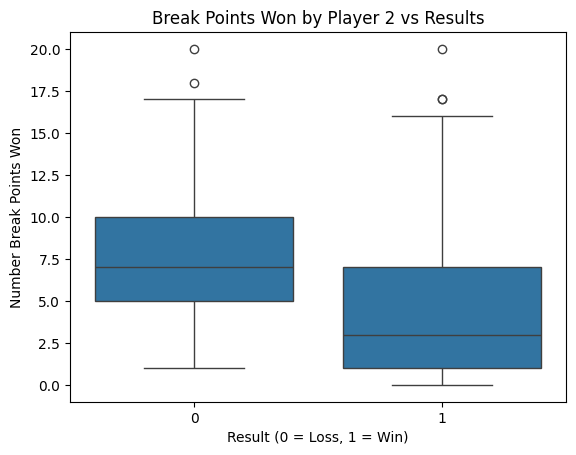

In [124]:
# Visual boxplot of Break Points Won vs Result (PLAYER 2)
sns.boxplot(x='Result', y='BPW.2', data=Female_Tennis_dataset_1)
plt.title('Break Points Won by Player 2 vs Results')
plt.xlabel('Result (0 = Loss, 1 = Win)')
plt.ylabel('Number Break Points Won')
plt.show()

## Feature and Target Sele

In [125]:
# Select features and target
features = ['FSP.1','FSP.2','FSW.1','FSW.2','SSP.1','SSP.2','SSW.1','SSW.2',
            'ACE.1','ACE.2','DBF.1','DBF.2','WNR.1','WNR.2','UFE.1','UFE.2',
            'BPC.1','BPC.2','BPW.1','BPW.2','NPA.1','NPA.2','NPW.1','NPW.2']

X = Female_Tennis_dataset_1[features]
y = Female_Tennis_dataset_1['Result']

## Train-Test Split

In [126]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

## Baseline Decision Tree

Baseline Decision Tree
CV Score: 0.8503753753753754
Number of tree nodes: 61


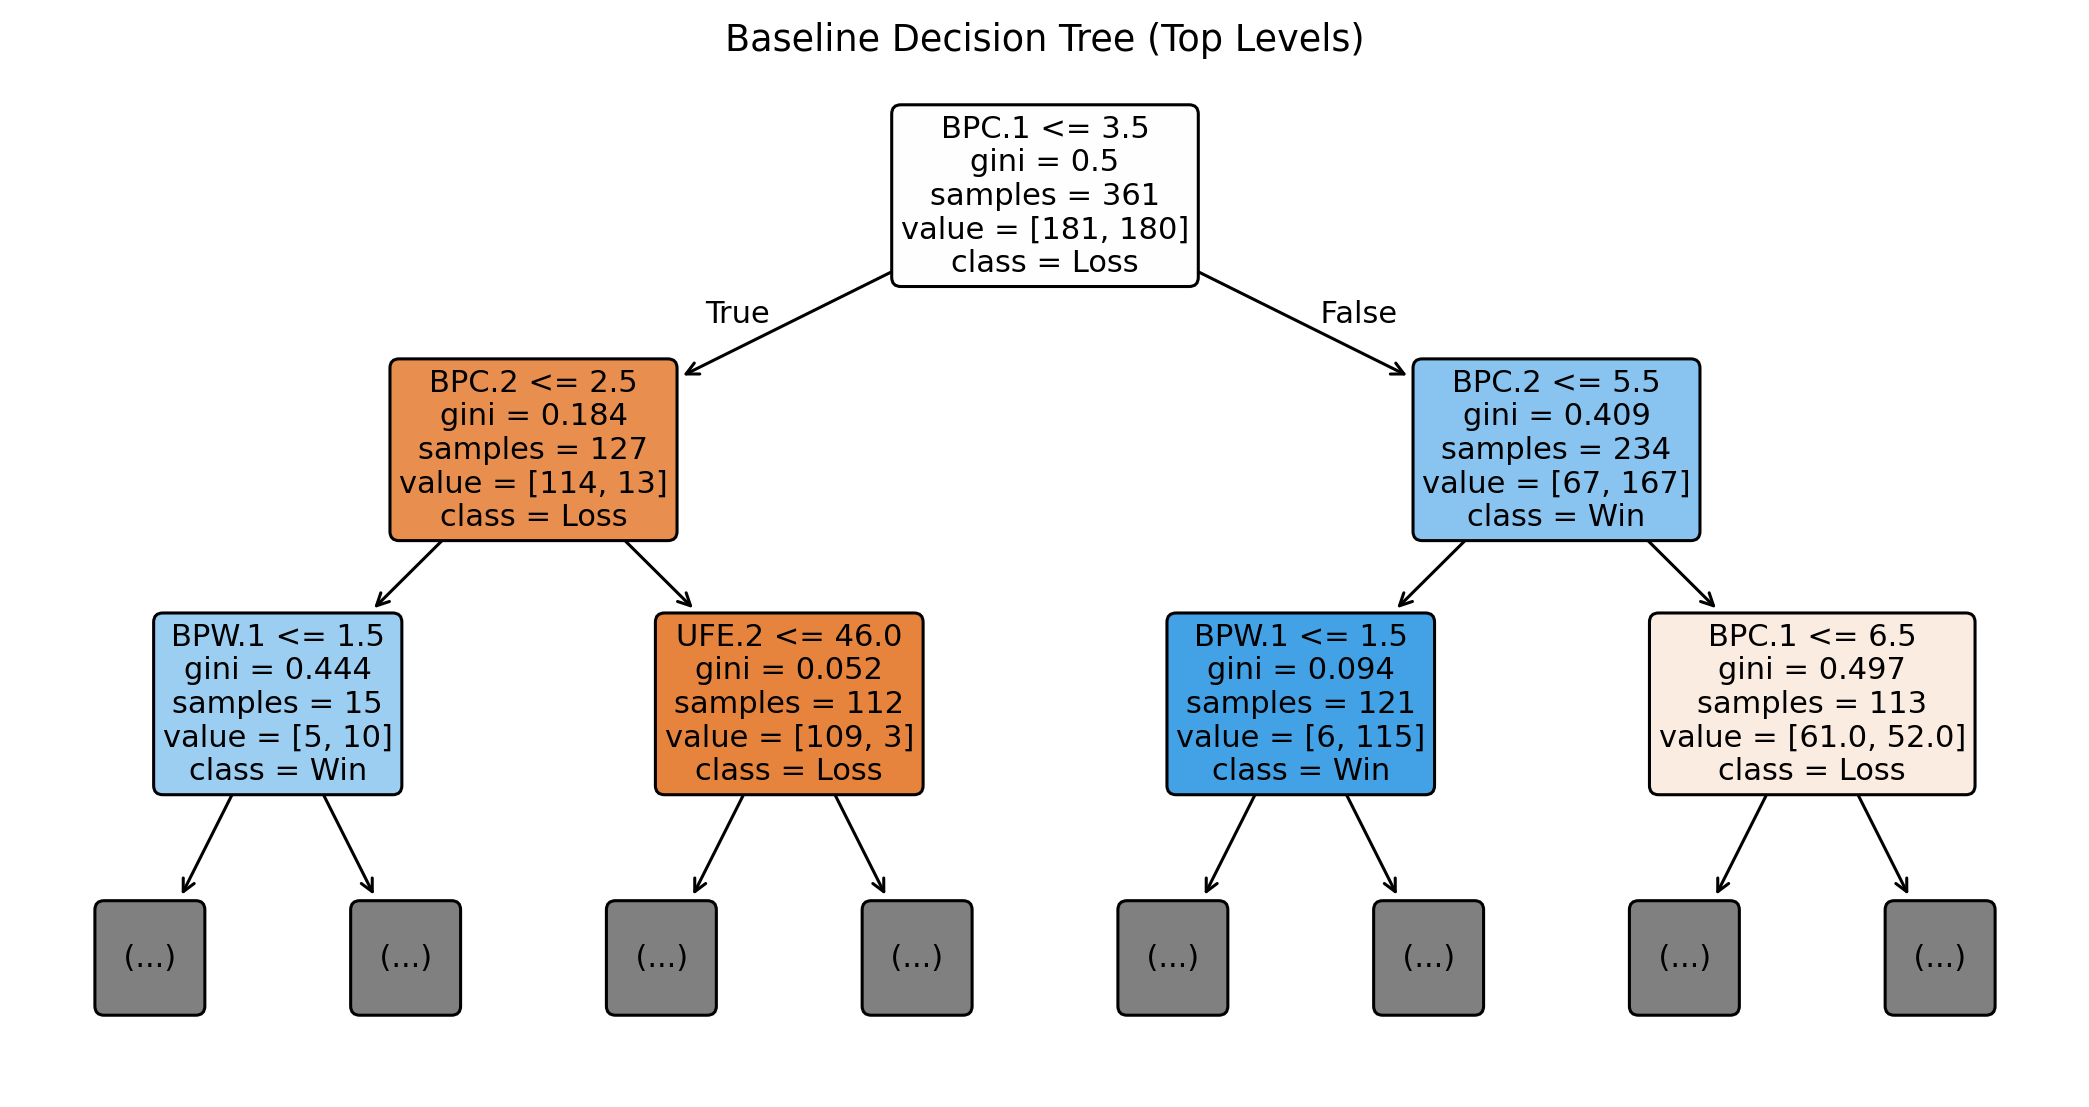

In [127]:
# Base Line Decision Tree
baseline_dt = tree.DecisionTreeClassifier(random_state=47)
baseline_dt.fit(X_train, y_train)

baseline_cv = cross_val_score(baseline_dt, X_train, y_train, cv=10)

print("Baseline Decision Tree")
print("CV Score:", np.mean(baseline_cv))
print("Number of tree nodes:", baseline_dt.tree_.node_count)

# Create Decision Tree
plt.figure(dpi=220, figsize=(12,6))
tree.plot_tree(baseline_dt,feature_names=X.columns, class_names=["Loss","Win"], filled=True, rounded=True, max_depth=2, fontsize=10)
plt.title("Baseline Decision Tree (Top Levels)")
plt.show()

## Decision Tree Hyperparameter Tuning

max_depth=1 | CV Score=0.776 | Node count=3
max_depth=2 | CV Score=0.801 | Node count=7
max_depth=3 | CV Score=0.809 | Node count=15
max_depth=4 | CV Score=0.842 | Node count=25
max_depth=5 | CV Score=0.875 | Node count=41
max_depth=6 | CV Score=0.881 | Node count=51
max_depth=7 | CV Score=0.861 | Node count=55
max_depth=8 | CV Score=0.864 | Node count=57
max_depth=9 | CV Score=0.867 | Node count=59
max_depth=10 | CV Score=0.867 | Node count=61


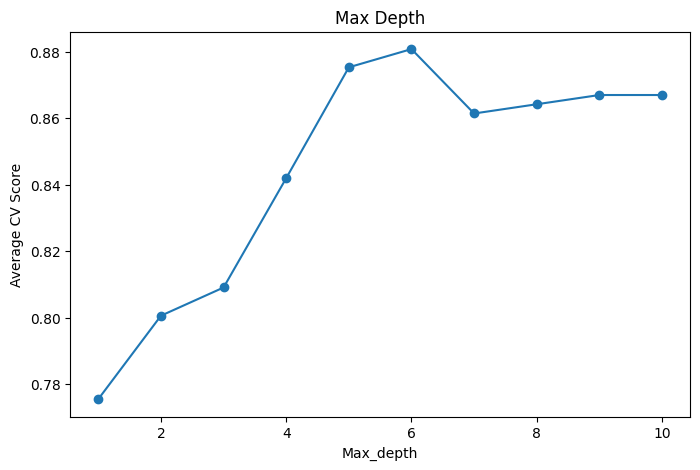

In [128]:
# Max_depth
depths = range(1, 11)
cv_scores_depth = []
node_counts_depth = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    cv = cross_val_score(dt, X_train, y_train, cv=10)
    cv_scores_depth.append(np.mean(cv))
    node_counts_depth.append(dt.tree_.node_count)
    print(f"max_depth={d} | CV Score={np.mean(cv):.3f} | Node count={dt.tree_.node_count}")

# Plot max_depth vs CV Score
plt.figure(figsize=(8,5))
plt.plot(depths, cv_scores_depth, marker='o')
plt.xlabel("Max_depth")
plt.ylabel("Average CV Score")
plt.title("Max Depth")
plt.show()

max_leaf_nodes=5 | CV Score=0.831 | Node count=9
max_leaf_nodes=10 | CV Score=0.903 | Node count=19
max_leaf_nodes=15 | CV Score=0.900 | Node count=29
max_leaf_nodes=20 | CV Score=0.909 | Node count=39
max_leaf_nodes=25 | CV Score=0.900 | Node count=49
max_leaf_nodes=30 | CV Score=0.900 | Node count=49


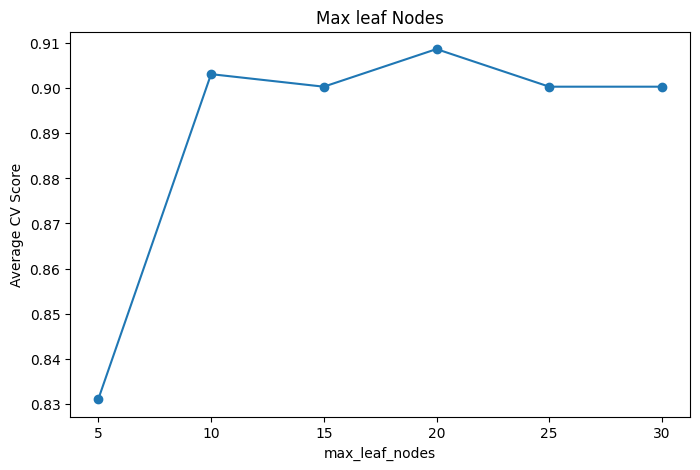

In [129]:
# Max_leaf_nodes
leaf_nodes_options = [5, 10, 15, 20, 25, 30]
cv_scores_leaf = []
node_counts_leaf = []

for leaves in leaf_nodes_options:
    dt = DecisionTreeClassifier(max_depth=optimal_depth, max_leaf_nodes=leaves, random_state=42)
    dt.fit(X, y)
    cv = cross_val_score(dt, X_train, y_train, cv=10)
    cv_scores_leaf.append(np.mean(cv))
    node_counts_leaf.append(dt.tree_.node_count)
    print(f"max_leaf_nodes={leaves} | CV Score={np.mean(cv):.3f} | Node count={dt.tree_.node_count}")

# Plot max_leaf_nodes vs CV Score
plt.figure(figsize=(8,5))
plt.plot(leaf_nodes_options, cv_scores_leaf, marker='o')
plt.xlabel("max_leaf_nodes")
plt.ylabel("Average CV Score")
plt.title("Max leaf Nodes")
plt.show()

## Final Optimised Model

Optimal max_leaf_nodes: 20
Final tree node count: 39


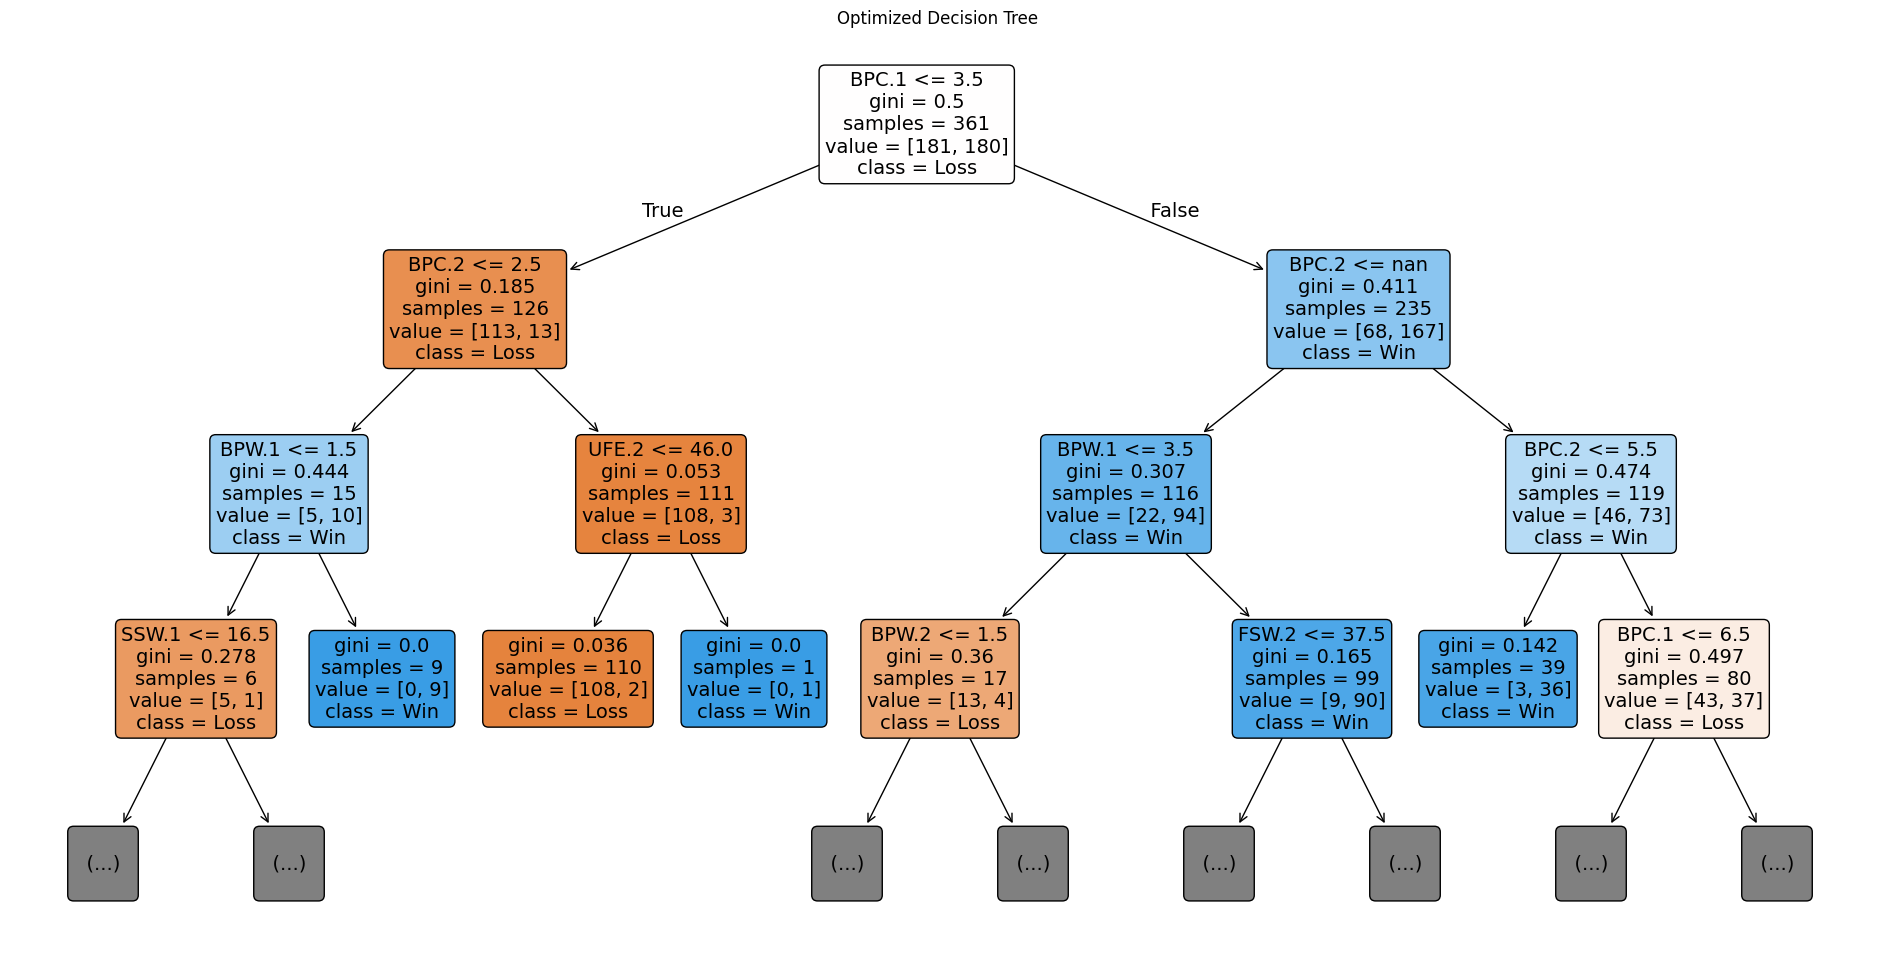

In [130]:
# Optimized Decision Tree
best_leaf_nodes = leaf_nodes_options[np.argmax(cv_scores_leaf)]
print("Optimal max_leaf_nodes:", best_leaf_nodes)

dt_final = DecisionTreeClassifier(max_depth=optimal_depth,max_leaf_nodes=best_leaf_nodes,random_state=42)
dt_final.fit(X_train, y_train)
print("Final tree node count:", dt_final.tree_.node_count)

plt.figure(figsize=(24, 12))
plot_tree(dt_final,feature_names=X.columns,class_names=["Loss","Win"],filled=True,rounded=True,fontsize=14,
    max_depth=3)
plt.title("Optimized Decision Tree ")
plt.show()

##  Model Evaluation

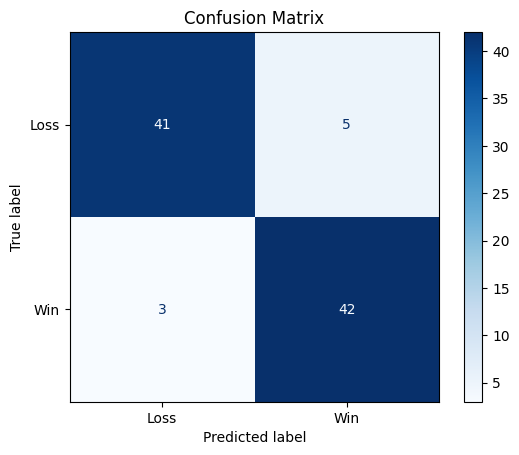

In [131]:
# Create predictions 
predict_opt = dt_final.predict(X_test)

cm = confusion_matrix(y_test, predict_opt)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss','Win'])
disp.plot(cmap='Blues', values_format='d')  # 'd' to show integers
plt.title("Confusion Matrix")
plt.show()

In [132]:
# Predict on test data
y_pred = dt_final.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("\nClassification Table:\n", classification_report(y_test, y_pred))

Accuracy: 0.9120879120879121
Precision: 0.8936170212765957
Recall: 0.9333333333333333
F1-Score: 0.9130434782608695

Classification Table:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91        46
           1       0.89      0.93      0.91        45

    accuracy                           0.91        91
   macro avg       0.91      0.91      0.91        91
weighted avg       0.91      0.91      0.91        91

